Step 1: Imports
---

In [15]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sb 

import warnings
# Ignore all FutureWarnings throughout the notebook
warnings.simplefilter(action='ignore', category=FutureWarning)


Step 2: Load built-in Titanic Dataset
---

In [16]:
# Load the built-in Titanic dataset 
df=sb.load_dataset('titanic')

# Inspect the first 5 rows
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


Step3: Advanced Multivariable Violin Plot
---



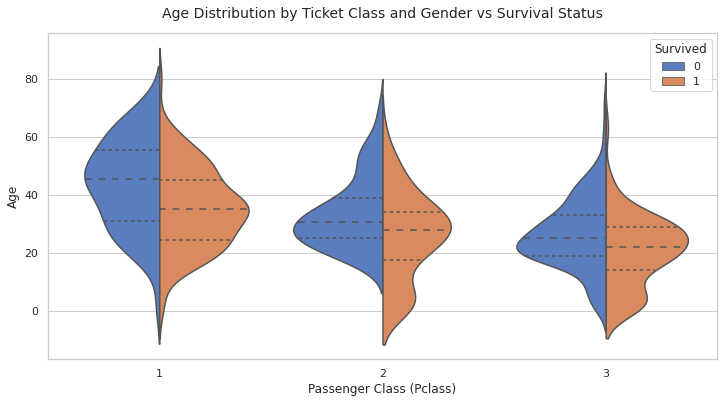

In [23]:

# Set clean aesthetic style
sb.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(12, 6))

# Plot Age distribution across Class and Gender, split by Survival
sb.violinplot(
    data=df, 
    x="pclass", 
    y="age", 
    hue="survived", 
    split=True,       # Splits the violins for direct 0 vs 1 comparison
    inner="quart",    # Shows internal data quartiles
    palette="muted"
)

plt.title("Age Distribution by Ticket Class and Gender vs Survival Status", fontsize=14, pad=15)
plt.xlabel("Passenger Class (Pclass)", fontsize=12)
plt.ylabel("Age", fontsize=12)
plt.legend(title="Survived", loc="upper right")

# Save directly to your repository structure
plt.savefig("violinplot_age_class_survival.png", bbox_inches="tight", dpi=300)
plt.show()


This chart replaces your baseline age boxplot with a violin plot. It tracks passenger age distributions split by Socioeconomic Class (pclass), Gender (sex), and Survival status (survived) simultaneously.


Age (Continuous Feature) vs Survived
---

<Axes: xlabel='sex', ylabel='age'>

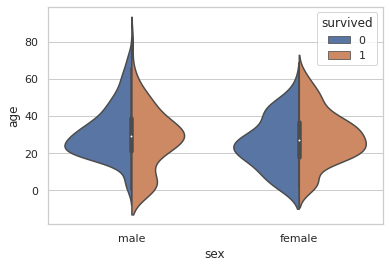

In [18]:

# Violinplot Displays distribution of data 
# across all levels of a category.
sb.violinplot(x ="sex", y ="age", hue ="survived", 
data = df, split = True)

---
This graph gives a summary of the age range of men, women and children who were saved. The survival rate is -  

Good for children.
High for women in the age range 20-50.
Less for men as the age increases.
---


Step 4: Family Size Feature Engineering & Analysis
---


0    2
1    2
2    1
3    2
4    1
Name: family_size, dtype: int64


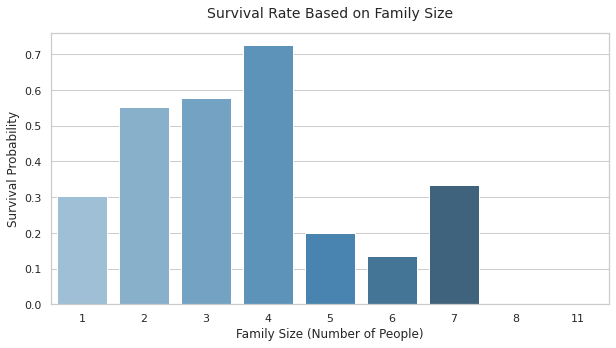

In [22]:

# Feature Engineering: Calculate family size
df['family_size'] = df['sibsp'] + df['parch'] + 1

print(df['family_size'].head())

# Visualize the survival rate per family size group
plt.figure(figsize=(10, 5))
sb.barplot(
    data=df, 
    x="family_size", 
    y="survived", 
    errorbar=None,    
    palette="Blues_d"
)

plt.title("Survival Rate Based on Family Size", fontsize=14, pad=15)
plt.xlabel("Family Size (Number of People)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)

plt.savefig("barplot_family_size_survival.png", bbox_inches="tight", dpi=300)
plt.show()
